# Exploratory Data Anlaysis - Credit Card

## Import Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

import sys
import os
sys.path.append(os.path.abspath('../'))
from src.eda_utils import (
    set_aesthetics,
    load_data,
    assess_quality,
    plot_class_distribution,
    plot_correlation_heatmap
)

# ── Aesthetics ──
FRAUD_PAL = {0: "#4C72B0", 1: "#DD4444", "0": "#4C72B0", "1": "#DD4444"}   # blue = normal, red = fraud
SEED = 42
set_aesthetics(palette_style="muted", font_scale=1.1)

Libraries loaded & global aesthetics set ✓


In [3]:
df_raw = load_data('../data/raw/creditcard.csv')

print("\nFraud Data sample:")
display(df_raw.head(3))

Loading data from: ../data/raw/creditcard.csv
Shape  : 284,807 rows × 31 columns
Memory : 70.6 MB

Fraud Data sample:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0


## Data Quality Assessment

In [4]:
df_raw.dtypes.to_frame("dtype")


,dtype
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [5]:
print("Statistical summary (core numeric columns)")
display(df_raw[["Time","Amount","Class"]].describe())


Statistical summary (core numeric columns)


,Time,Amount,Class
count,284807.0000,284807.0000,284807.0000
mean,94813.8596,88.3496,0.0017
std,47488.1460,250.1201,0.0415
min,0.0000,0.0000,0.0000
25%,54201.5000,5.6000,0.0000
50%,84692.0000,22.0000,0.0000
75%,139320.5000,77.1650,0.0000
max,172792.0000,25691.1600,1.0000


## Data Quality Assessment

In [6]:
quality_report, n_dup = assess_quality(df_raw)

No missing values detected.

Duplicate rows : 1,081


## Data Cleaning

In [7]:
df = df_raw.copy()
# Step 1-2: drop rows missing Class or Amount
before = len(df)
df = df.dropna(subset=["Class", "Amount"])
print(f"Dropped {before - len(df):,} rows missing Class / Amount")
# Step 3: remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df):,} duplicate rows")
# Step 4: cast dtypes
df["Class"] = df["Class"].astype(int)
df["Time"]  = df["Time"].astype(int)
print(f"\nCleaned dataset : {len(df):,} rows × {df.shape[1]} columns")
df.dtypes.to_frame("dtype").T


Dropped 0 rows missing Class / Amount
Removed 1,081 duplicate rows

Cleaned dataset : 283,726 rows × 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
dtype,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64


## Class Distribution & Imbalance

,count,percent_%
Normal (0),283253,99.8333
Fraud (1),473,0.1667



Imbalance ratio (Normal : Fraud) = 599 : 1
Saved class distribution plot to: ../notebooks/cc_class_distribution.png


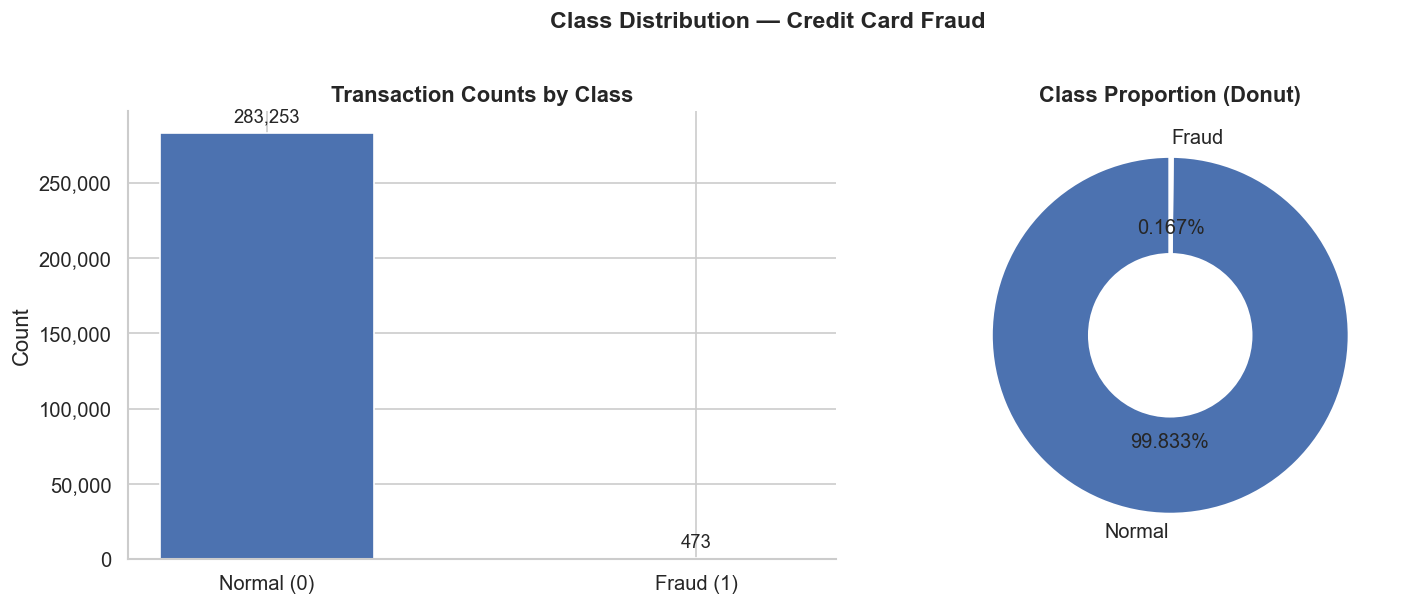

In [8]:
plot_class_distribution(df, "Class", "Class Distribution — Credit Card Fraud", palette=FRAUD_PAL, save_path="../notebooks/cc_class_distribution.png")

## Transaction Amount Analysis

In [10]:
from pandas.io.formats.style import Styler
# Per-class amount statistics
amt_stats = df.groupby("Class")["Amount"].describe().T
amt_stats.columns = ["Normal", "Fraud"]
display(amt_stats.style.format("{:.4f}"))

ImportError: `Import Jinja2` failed. DataFrame.style requires jinja2. Use pip or conda to install the Jinja2 package.

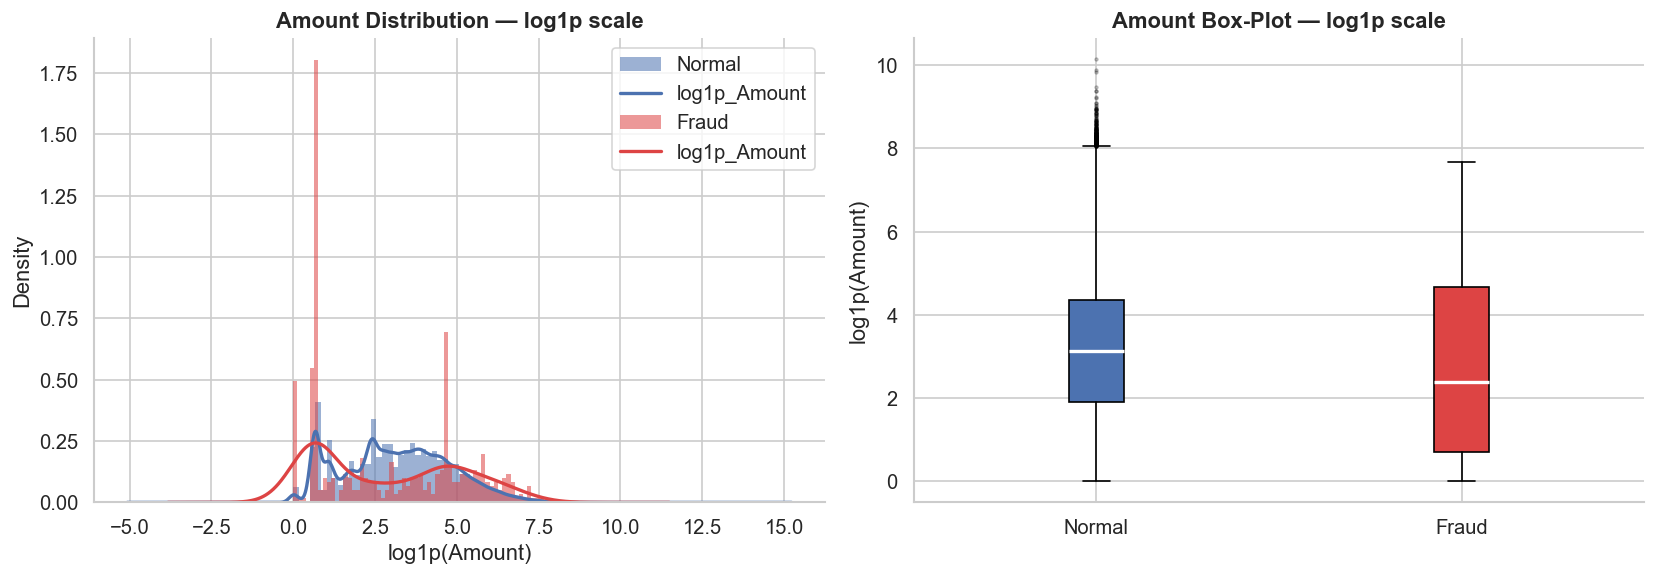

In [ ]:
# log1p transform avoids -inf for Amount = 0
df["log1p_Amount"] = np.log1p(df["Amount"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE per class (log1p scale)
for cls in [0, 1]:
    color = FRAUD_PAL[cls]
    subset = df[df["Class"] == cls]["log1p_Amount"]
    axes[0].hist(subset, bins=60, alpha=0.55, color=color,
                 label=["Normal","Fraud"][cls], density=True, edgecolor="none")
    subset.plot.kde(ax=axes[0], color=color, linewidth=2)
axes[0].set_title("Amount Distribution — log1p scale", fontweight="bold")
axes[0].set_xlabel("log1p(Amount)")
axes[0].legend()

# Boxplot per class
df_plot = df.copy()
df_plot["Class_label"] = df_plot["Class"].map({0:"Normal", 1:"Fraud"})
bp = axes[1].boxplot(
    [df_plot[df_plot["Class"]==0]["log1p_Amount"],
     df_plot[df_plot["Class"]==1]["log1p_Amount"]],
    labels=["Normal","Fraud"],
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
    boxprops=dict(facecolor="#4C72B0"),
    flierprops=dict(marker=".", alpha=0.3, markersize=3)
)
bp["boxes"][1].set_facecolor(FRAUD_PAL[1])
axes[1].set_title("Amount Box-Plot — log1p scale", fontweight="bold")
axes[1].set_ylabel("log1p(Amount)")

plt.tight_layout()
plt.show()

## Transaction Time Analysis

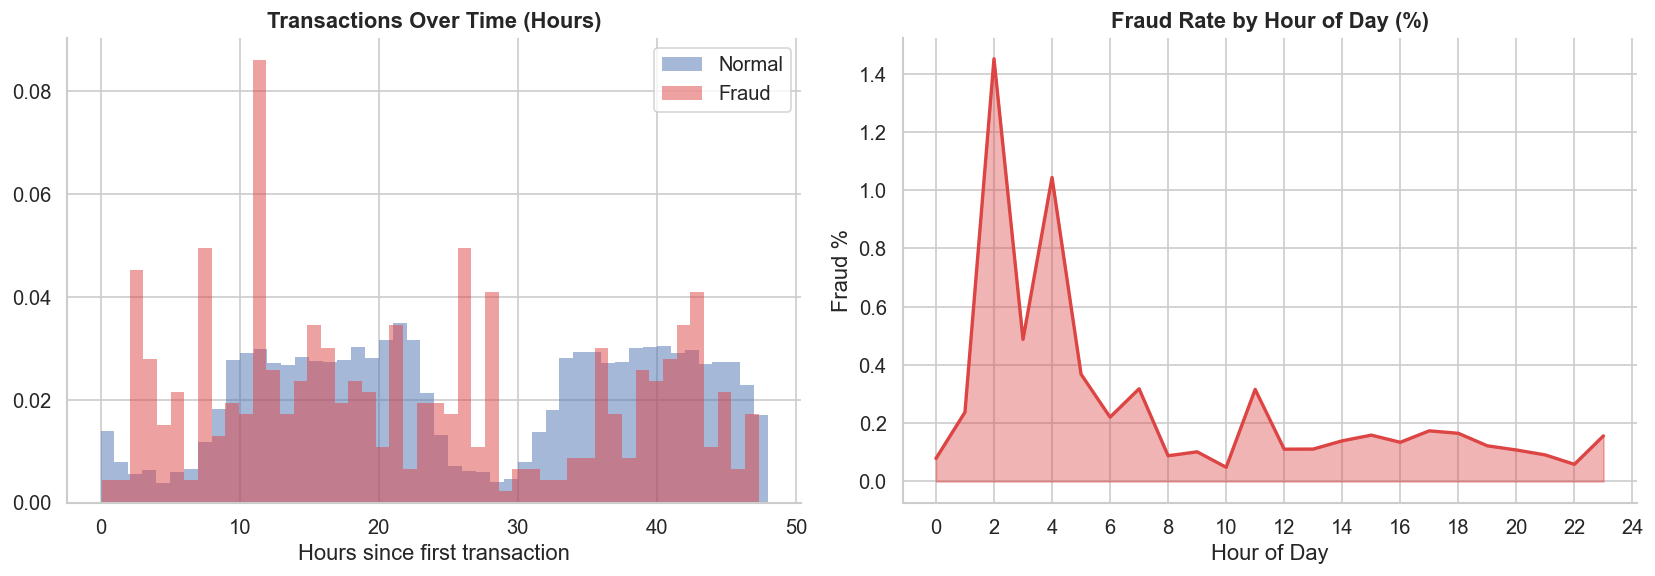

In [ ]:
# Convert seconds → hour-of-day (dataset spans 2 days)
df["hour_of_day"] = (df["Time"] // 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE per class
for cls in [0, 1]:
    color = FRAUD_PAL[cls]
    subset = df[df["Class"] == cls]["Time"]
    axes[0].hist(subset / 3600, bins=48, alpha=0.5, color=color,
                 label=["Normal","Fraud"][cls], density=True, edgecolor="none")
axes[0].set_title("Transactions Over Time (Hours)", fontweight="bold")
axes[0].set_xlabel("Hours since first transaction")
axes[0].legend()

# Hourly fraud rate
hourly = df.groupby("hour_of_day")["Class"].agg(["sum","count"])
hourly["fraud_rate"] = hourly["sum"] / hourly["count"] * 100
axes[1].fill_between(hourly.index, hourly["fraud_rate"],
                     alpha=0.4, color=FRAUD_PAL[1])
axes[1].plot(hourly.index, hourly["fraud_rate"],
             color=FRAUD_PAL[1], linewidth=2)
axes[1].set_title("Fraud Rate by Hour of Day (%)", fontweight="bold")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Fraud %")
axes[1].xaxis.set_major_locator(plt.MultipleLocator(2))

plt.tight_layout()
plt.show()

## Feature Correlation with Class

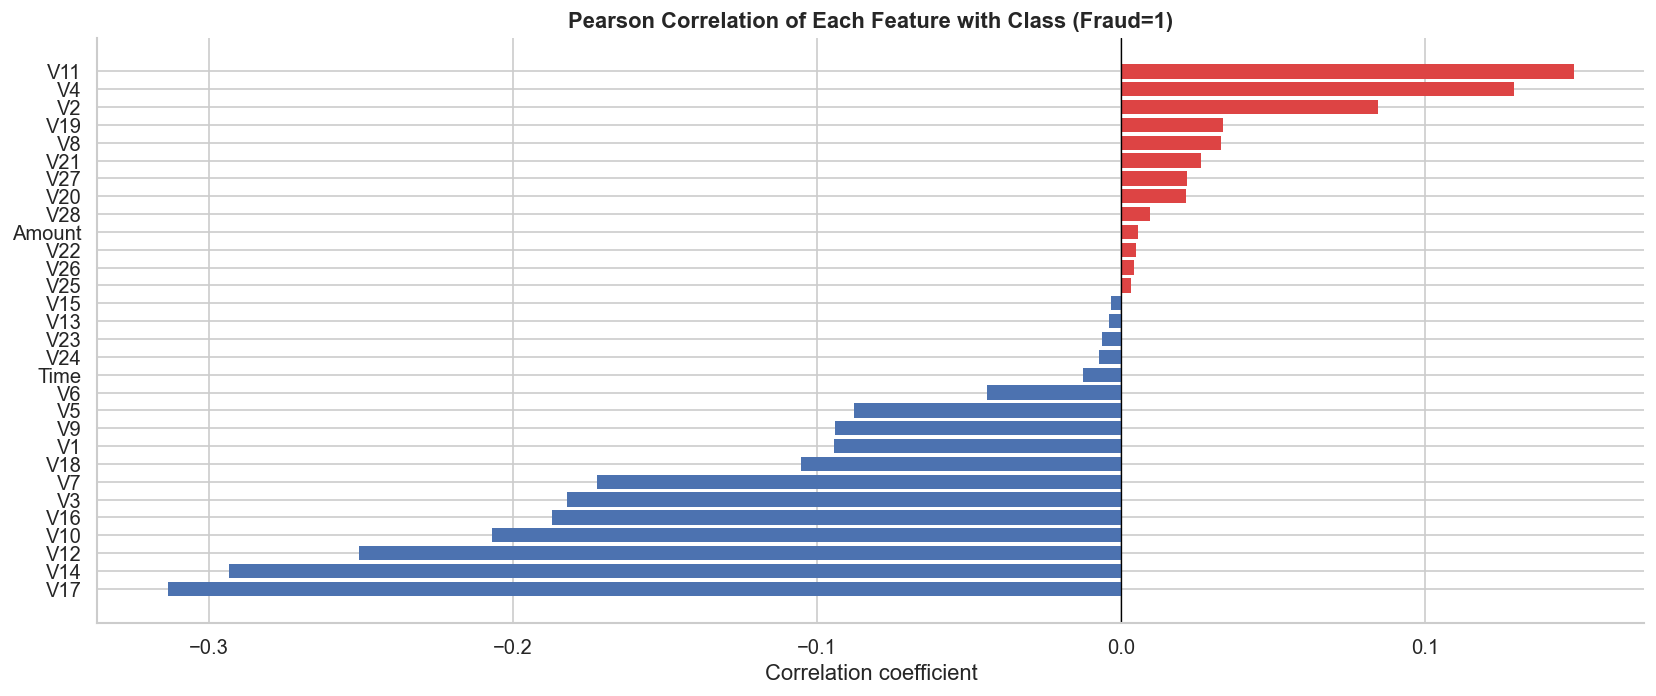

Top 5 NEGATIVE correlations (most protective against fraud flag):


,r
V17,-0.3135
V14,-0.2934
V12,-0.2507
V10,-0.2070
V16,-0.1872



Top 5 POSITIVE correlations (most indicative of fraud):


,r
V8,0.0331
V19,0.0336
V2,0.0846
V4,0.1293
V11,0.1491


In [ ]:
corr_with_class = (
    df.drop(columns=["log1p_Amount","hour_of_day"], errors="ignore")
      .corr(numeric_only=True)["Class"]
      .drop("Class")
      .sort_values()
)

# Bar chart
fig, ax = plt.subplots(figsize=(14, 6))
colors = [FRAUD_PAL[1] if v > 0 else FRAUD_PAL[0] for v in corr_with_class]
ax.barh(corr_with_class.index, corr_with_class.values, color=colors, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation of Each Feature with Class (Fraud=1)", fontweight="bold")
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

print("Top 5 NEGATIVE correlations (most protective against fraud flag):")
display(corr_with_class.head(5).to_frame("r"))
print("\nTop 5 POSITIVE correlations (most indicative of fraud):")
display(corr_with_class.tail(5).to_frame("r"))

##  Feature Distributions by Class


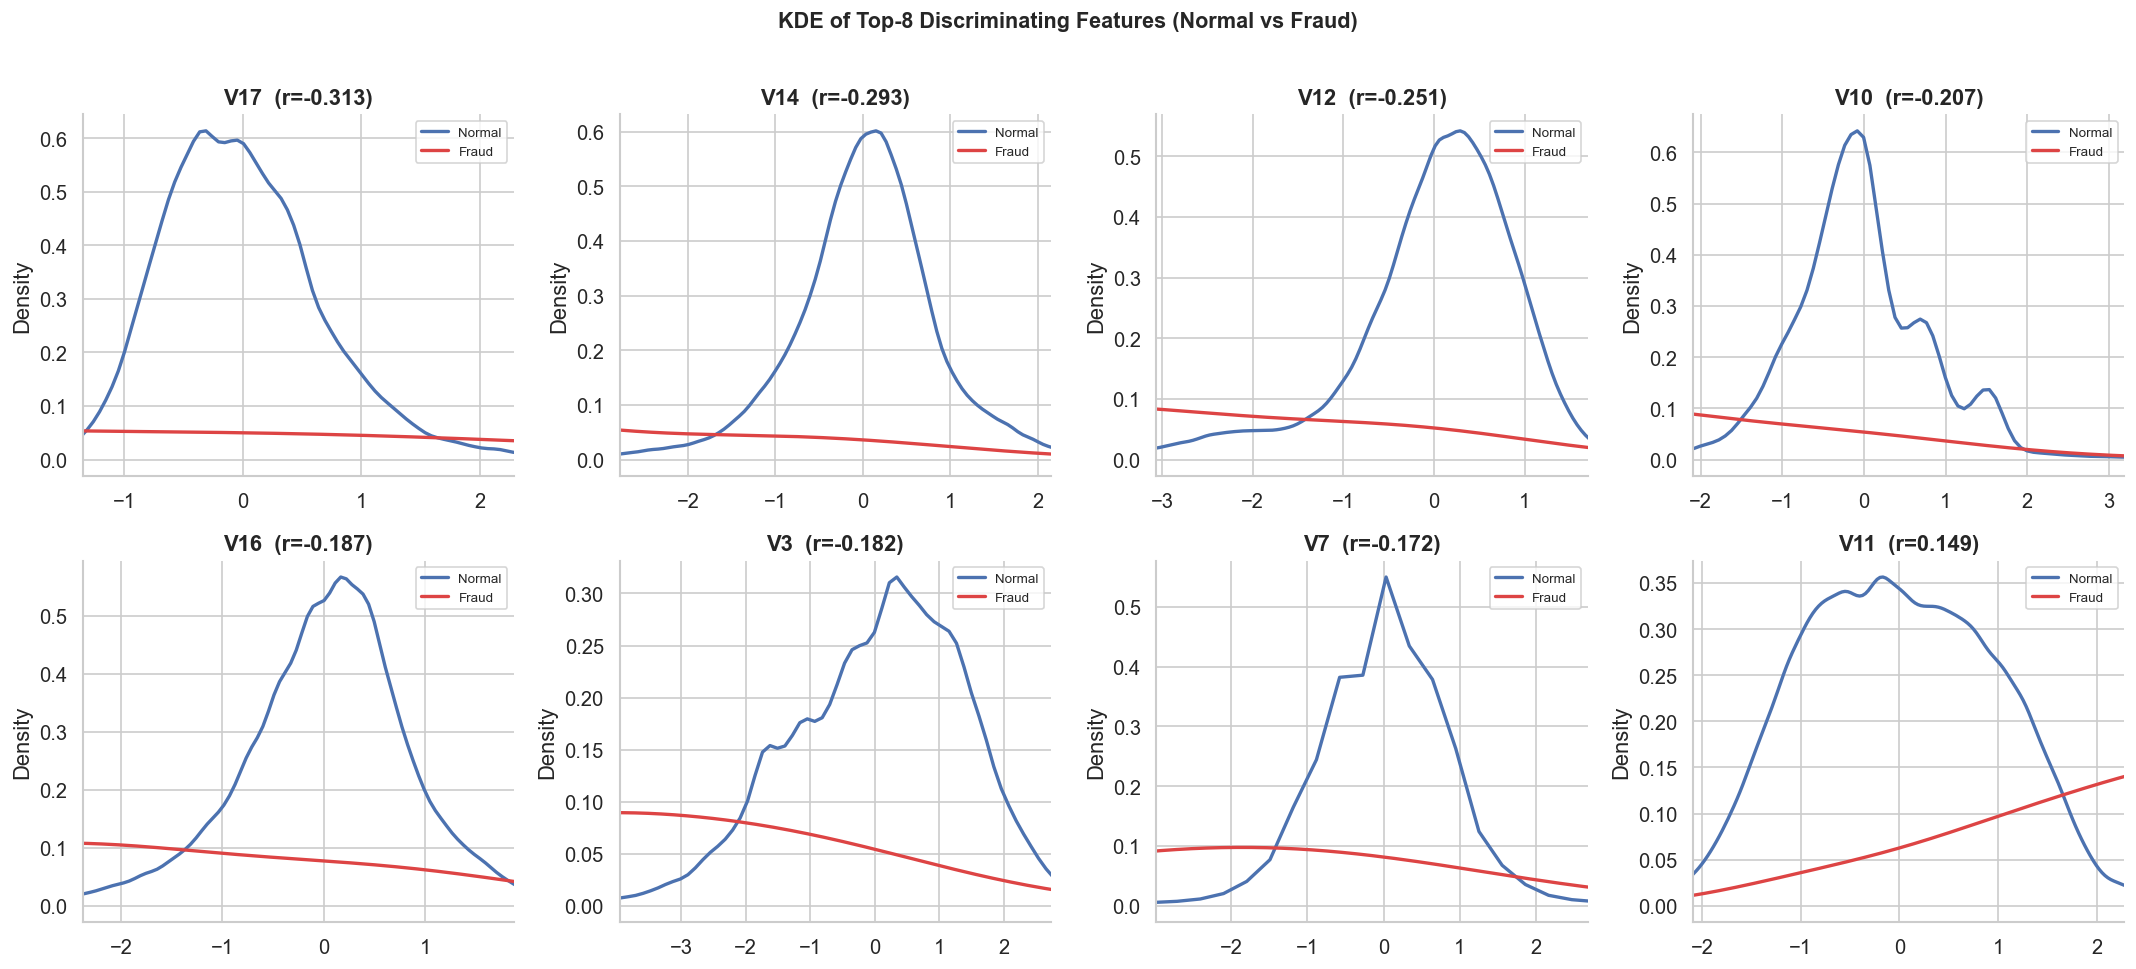

In [ ]:
top8 = corr_with_class.abs().sort_values(ascending=False).head(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(top8):
    ax = axes[i]
    for cls in [0, 1]:
        data = df[df["Class"] == cls][feat]
        data.plot.kde(ax=ax, color=FRAUD_PAL[cls],
                      label=["Normal","Fraud"][cls], linewidth=2)
    ax.set_title(f"{feat}  (r={corr_with_class[feat]:.3f})", fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=8)
    # remove extreme tails for readability
    q01, q99 = df[feat].quantile([0.01, 0.99])
    ax.set_xlim(q01, q99)
plt.suptitle("KDE of Top-8 Discriminating Features (Normal vs Fraud)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## Bivariate Box-Plots — Top Discriminating Features

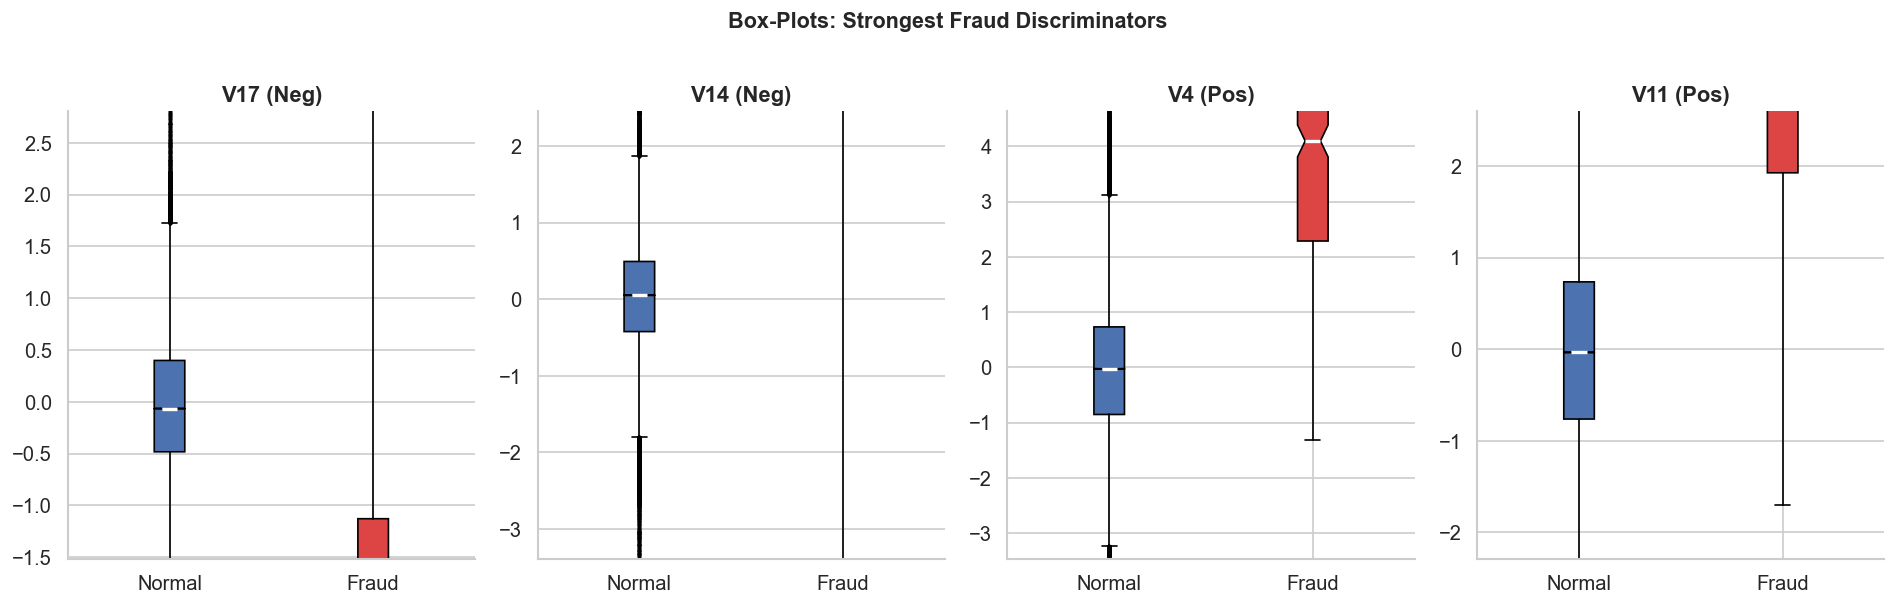

In [ ]:
top_neg = corr_with_class.head(2).index.tolist()
top_pos = corr_with_class.tail(2).index.tolist()
plot_feats = top_neg + top_pos

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, feat in zip(axes, plot_feats):
    data_groups = [df[df["Class"]==c][feat] for c in [0,1]]
    bp = ax.boxplot(data_groups, labels=["Normal","Fraud"],
                    patch_artist=True, notch=True,
                    medianprops=dict(color="white", linewidth=2),
                    flierprops=dict(marker=".", alpha=0.2, markersize=2))
    for patch, color in zip(bp["boxes"], FRAUD_PAL.values()):
        patch.set_facecolor(color)
    direction = "Neg" if feat in top_neg else "Pos"
    ax.set_title(f"{feat} ({direction})", fontweight="bold")
    q01, q99 = df[feat].quantile([0.005, 0.995])
    ax.set_ylim(q01, q99)

plt.suptitle("Box-Plots: Strongest Fraud Discriminators",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Feature Skewness

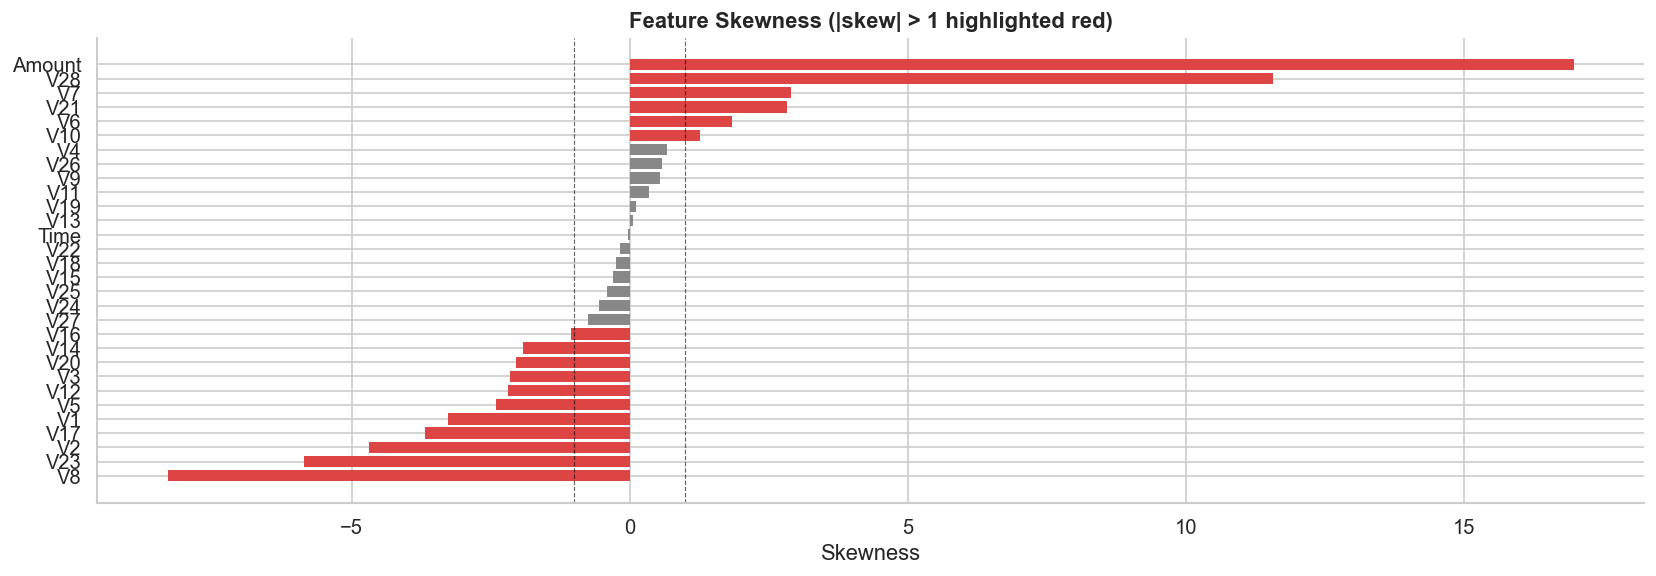

Highly skewed features (|skew|>1): 17


In [ ]:
skew = df[[c for c in df.columns if c not in
             ("Class","log1p_Amount","hour_of_day")]
           ].skew(numeric_only=True).sort_values()

fig, ax = plt.subplots(figsize=(14, 5))
colors = [FRAUD_PAL[1] if abs(v) > 1 else "#888888" for v in skew]
ax.barh(skew.index, skew.values, color=colors, edgecolor="none")
ax.axvline(-1, color="black", linestyle="--", linewidth=0.7, alpha=0.6)
ax.axvline( 1, color="black", linestyle="--", linewidth=0.7, alpha=0.6)
ax.set_title("Feature Skewness (|skew| > 1 highlighted red)", fontweight="bold")
ax.set_xlabel("Skewness")
plt.tight_layout()
plt.show()
print(f"Highly skewed features (|skew|>1): {(skew.abs()>1).sum()}")

## 12 · Summary of EDA Insights

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **Extreme imbalance** — fraud ≈ 0.31 % of transactions | Models must use class-weighting, SMOTE, or threshold tuning; accuracy is misleading |
| 2 | **Cleaning removed < 0.5 %** of rows | Dataset is essentially complete; no complex imputation needed |
| 3 | **Amount** is highly right-skewed with a long tail | Log scaling or `log1p(Amount)` is essential for models sensitive to distribution |
| 4 | **Time** shows mild fraud variation across hours | Hour-of-day features may add signal for temporal patterns |
| 5 | **Merchant and device risk scores** are among the strongest fraud signals | These should be prioritized in baseline models |
| 6 | **International transactions** and `online_order` have higher fraud rates | Encode these categorical flags for tree and linear models |
| 7 | **Card age and number of items** provide additional behavioral context | Use them in interaction and ratio features |
| 8 | **High class imbalance** means PR-AUC and thresholded F1 are better evaluation choices than accuracy | Favor precision-recall based model selection |

### Recommended Next Steps
- Feature engineering: `log1p_Amount`, `hour_of_day`, `merchant_risk × device_risk`, `international` and `online_order` encoding
- Imbalance handling: evaluate SMOTE, class-weighting, and threshold tuning using PR-AUC
- Baseline models: Logistic Regression, Random Forest, XGBoost
- Evaluation metric: **Average Precision (PR-AUC)** and **F1 at threshold 0.5**
